<a href="https://colab.research.google.com/github/SoupBoi1/cpre545_final/blob/main/imagewatermark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install bchlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.0/68.0 kB 3.7 MB/s eta 0:00:00


In [2]:
from PIL import Image
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO
import cv2 as cv
from scipy.fftpack import dct, idct
import math
import bchlib

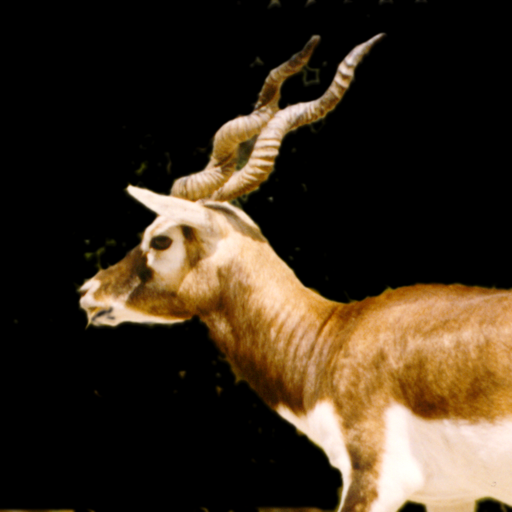

In [3]:

image_url = 'https://people.math.sc.edu/Burkardt/data/png/blackbuck.png'
response = requests.get(image_url)
image_data = response.content
img = Image.open(BytesIO(image_data))

display(img)

In [4]:
ycbcr_img = np.array(img.convert('YCbCr'))
np.shape(ycbcr_img)


(512, 512, 3)

In [5]:
display(ycbcr_img[0])
display(ycbcr_img[1])
display(ycbcr_img[2])

array([[  0, 128, 128],
       [  0, 128, 128],
       [  0, 128, 128],
       ...,
       [  0, 128, 128],
       [  0, 128, 128],
       [  0, 128, 128]], dtype=uint8)

array([[  0, 128, 128],
       [  0, 128, 128],
       [  0, 128, 128],
       ...,
       [  0, 128, 128],
       [  0, 128, 128],
       [  0, 128, 128]], dtype=uint8)

array([[  0, 128, 128],
       [  0, 128, 128],
       [  0, 128, 128],
       ...,
       [  0, 128, 128],
       [  0, 128, 128],
       [  0, 128, 128]], dtype=uint8)

In [6]:

ycbcr_img = img.convert('YCbCr')



# JPEG Compression from Scratch

JPEG compression involves several key steps:

1.  **Color Space Conversion**: Convert the RGB image to YCbCr. Y represents luminance (brightness), and Cb and Cr represent chrominance (color).
2.  **Chroma Subsampling**: Since the human eye is less sensitive to color variations than brightness, the Cb and Cr components are often downsampled (e.g., 4:2:0, 4:2:2).
3.  **Blocking**: Each component (Y, Cb, Cr) is divided into 8x8 pixel blocks.
4.  **Discrete Cosine Transform (DCT)**: Apply a 2D DCT to each 8x8 block. This transforms the spatial domain data into the frequency domain.
5.  **Quantization**: The DCT coefficients are then quantized using a quantization matrix. This step is lossy and controls the compression level. High-frequency coefficients are typically quantized more aggressively.
6.  **Entropy Encoding (not fully implemented here)**: The quantized coefficients are then losslessly compressed using techniques like run-length encoding and Huffman coding. For this "from scratch" demonstration, we'll focus on the lossy steps up to quantization and inverse transformation.

Original Y shape: (512, 512)
Original Cb shape: (512, 512)
Original Cr shape: (512, 512)


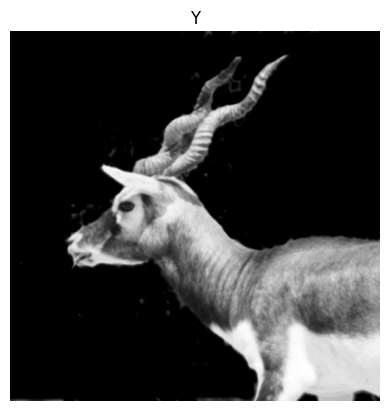

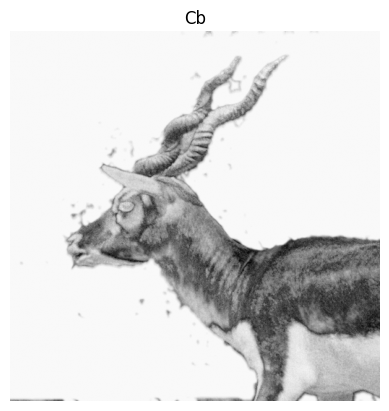

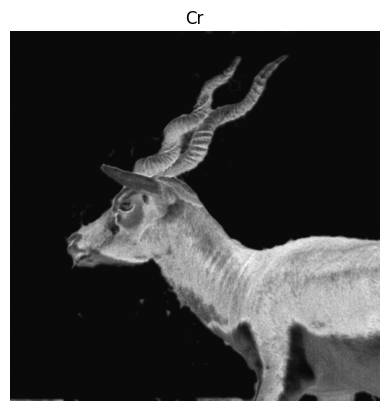

In [7]:

# The ycbcr_img from previous steps is a PIL Image. Convert it to a numpy array for processing.
ycbcr_array = np.array(img.convert('YCbCr'))

# Separate Y, Cb, Cr channels
Y = ycbcr_array[:, :, 0]
Cb = ycbcr_array[:, :, 1]
Cr = ycbcr_array[:, :, 2]

print(f"Original Y shape: {Y.shape}")
print(f"Original Cb shape: {Cb.shape}")
print(f"Original Cr shape: {Cr.shape}")

#plt.figure(figsize=(10, 8))
plt.imshow(Y,cmap=plt.cm.gray)
plt.title('Y')
plt.axis('off')
plt.show()
plt.imshow(Cb,cmap=plt.cm.gray)
plt.title('Cb')
plt.axis('off')
plt.show()
plt.imshow(Cr,cmap=plt.cm.gray)
plt.title('Cr')
plt.axis('off')
plt.show()

#### Chroma Subsampling (4:2:0)

We'll downsample the Cb and Cr channels by a factor of 2 in both height and width. This reduces the amount of color information, which is less perceptible to the human eye.

Subsampled Cb shape: (256, 256)
Subsampled Cr shape: (256, 256)


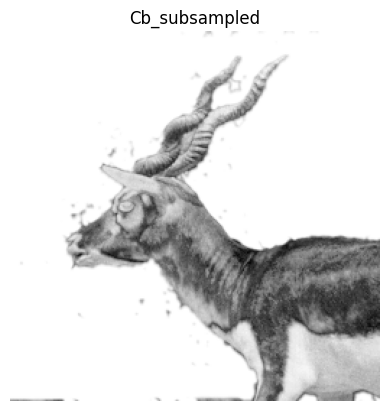

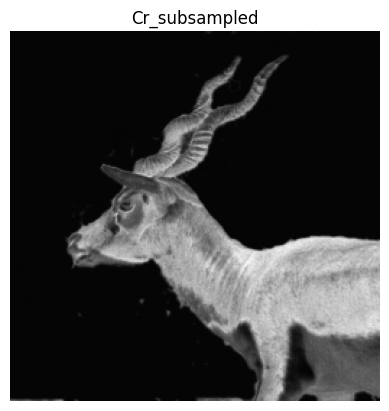

In [8]:
# Simple 4:2:0 subsampling (average 2x2 blocks)
Cb_subsampled = Cb.reshape(Cb.shape[0] // 2, 2, Cb.shape[1] // 2, 2).mean(axis=(1, 3))
Cr_subsampled = Cr.reshape(Cr.shape[0] // 2, 2, Cr.shape[1] // 2, 2).mean(axis=(1, 3))

print(f"Subsampled Cb shape: {Cb_subsampled.shape}")
print(f"Subsampled Cr shape: {Cr_subsampled.shape}")
plt.imshow(Cb_subsampled,cmap=plt.cm.gray)
plt.title('Cb_subsampled')
plt.axis('off')
plt.show()
plt.imshow(Cr_subsampled,cmap=plt.cm.gray)
plt.title('Cr_subsampled')
plt.axis('off')
plt.show()

#### DCT and Quantization

Next, each channel is divided into 8x8 blocks. For each block, a 2D DCT is applied to transform spatial data into frequency components. These components are then quantized using a quantization matrix, which is crucial for the lossy compression.

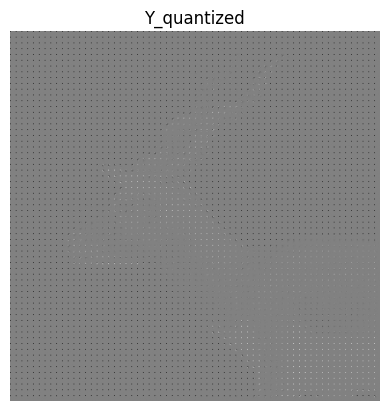

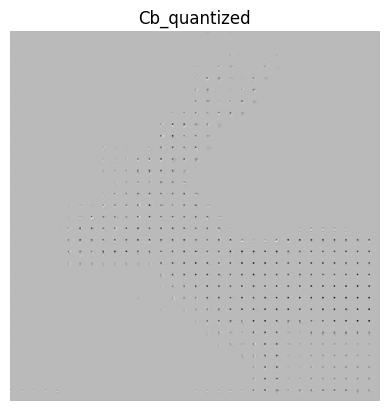

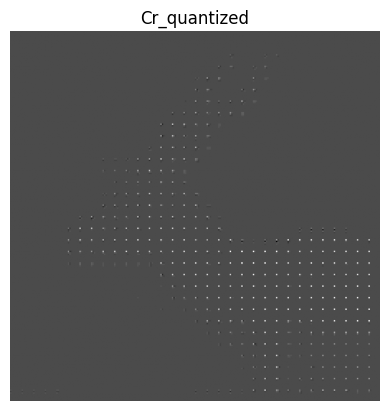

DCT and Quantization applied.


In [9]:
# Define quantization matrices (example values for luminance and chrominance)
# These are simplified for demonstration; actual JPEG uses standard tables.

# Luminance Quantization Matrix (Q_Y)
Q_Y = np.array([
    [16, 11, 10, 16, 24, 40, 51, 61],
    [12, 12, 14, 19, 26, 58, 60, 55],
    [14, 13, 16, 24, 40, 57, 69, 56],
    [14, 17, 22, 29, 51, 87, 80, 62],
    [18, 22, 37, 56, 68, 109, 103, 77],
    [24, 35, 55, 64, 81, 104, 113, 92],
    [49, 64, 78, 87, 103, 121, 120, 101],
    [72, 92, 95, 98, 112, 100, 103, 99]
])

# Chrominance Quantization Matrix (Q_C)
Q_C = np.array([
    [17, 18, 24, 47, 99, 99, 99, 99],
    [18, 21, 26, 66, 99, 99, 99, 99],
    [24, 26, 40, 66, 99, 99, 99, 99],
    [47, 66, 66, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99]
])

def apply_dct_quantization(channel, Q_matrix):
    # Ensure the channel dimensions are multiples of 8
    h, w = channel.shape
    h_padded, w_padded = int(np.ceil(h/8)*8), int(np.ceil(w/8)*8)
    padded_channel = np.zeros((h_padded, w_padded))
    padded_channel[:h, :w] = channel

    quantized_coeffs = np.zeros_like(padded_channel)

    for i in range(0, h_padded, 8):
        for j in range(0, w_padded, 8):
            block = padded_channel[i:i+8, j:j+8].astype(np.float32) - 128 # Subtract 128 for DCT
            dct_coeffs = dct(dct(block.T, norm='ortho').T, norm='ortho') # 2D DCT
            quantized_block = np.round(dct_coeffs / Q_matrix) # Quantization
            quantized_coeffs[i:i+8, j:j+8] = quantized_block

    return quantized_coeffs, h, w # Return original dimensions for later cropping

# Apply to Y, Cb, Cr
Y_quantized, Y_h, Y_w = apply_dct_quantization(Y, Q_Y)
Cb_quantized, Cb_h, Cb_w = apply_dct_quantization(Cb_subsampled, Q_C)
Cr_quantized, Cr_h, Cr_w = apply_dct_quantization(Cr_subsampled, Q_C)


plt.imshow(Y_quantized,cmap=plt.cm.gray)
plt.title('Y_quantized')
plt.axis('off')
plt.show()

plt.imshow(Cb_quantized,cmap=plt.cm.gray)
plt.title('Cb_quantized')
plt.axis('off')
plt.show()

plt.imshow(Cr_quantized,cmap=plt.cm.gray)
plt.title('Cr_quantized')
plt.axis('off')
plt.show()
print("DCT and Quantization applied.")

#### Inverse Quantization and Inverse DCT

To reconstruct the image, we reverse the process: dequantize the coefficients and apply the Inverse Discrete Cosine Transform (IDCT).

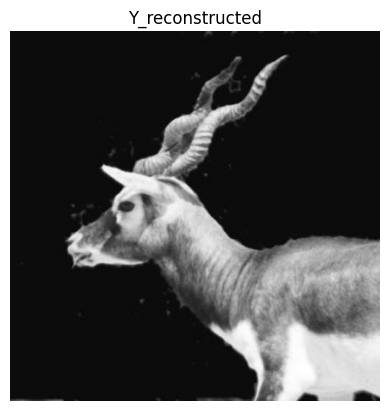

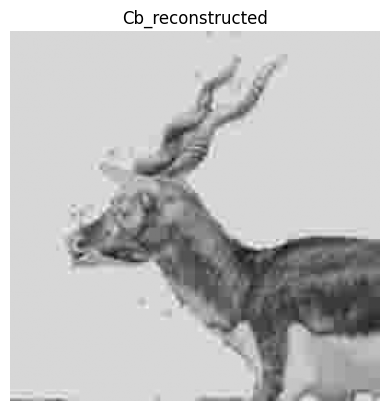

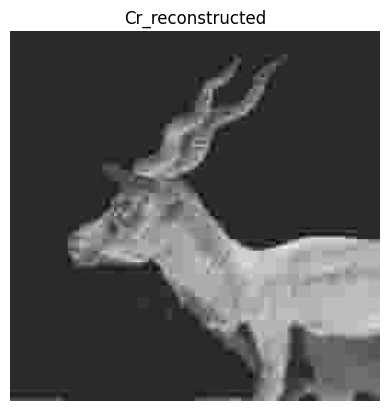

Dequantization and IDCT applied.


In [10]:
def apply_idct_dequantization(quantized_coeffs, Q_matrix, original_h, original_w):
    h_padded, w_padded = quantized_coeffs.shape
    reconstructed_channel = np.zeros_like(quantized_coeffs, dtype=np.float32)

    for i in range(0, h_padded, 8):
        for j in range(0, w_padded, 8):
            quantized_block = quantized_coeffs[i:i+8, j:j+8]
            dequantized_block = quantized_block * Q_matrix # Dequantization
            idct_block = idct(idct(dequantized_block.T, norm='ortho').T, norm='ortho') # 2D IDCT
            reconstructed_block = idct_block + 128 # Add 128 back
            reconstructed_channel[i:i+8, j:j+8] = reconstructed_block

    # Crop back to original dimensions
    return reconstructed_channel[:original_h, :original_w]

# Apply to all channels
Y_reconstructed = apply_idct_dequantization(Y_quantized, Q_Y, Y_h, Y_w)
Cb_reconstructed = apply_idct_dequantization(Cb_quantized, Q_C, Cb_h, Cb_w)
Cr_reconstructed = apply_idct_dequantization(Cr_quantized, Q_C, Cr_h, Cr_w)


plt.imshow(Y_reconstructed,cmap=plt.cm.gray)
plt.title('Y_reconstructed')
plt.axis('off')
plt.show()

plt.imshow(Cb_reconstructed,cmap=plt.cm.gray)
plt.title('Cb_reconstructed')
plt.axis('off')
plt.show()

plt.imshow(Cr_reconstructed,cmap=plt.cm.gray)
plt.title('Cr_reconstructed')
plt.axis('off')
plt.show()
print("Dequantization and IDCT applied.")

#### Chroma Upsampling and YCbCr to RGB Conversion

Finally, we upsample the Cb and Cr channels back to their original size and combine them with the Y channel. Then, convert the YCbCr image back to RGB for display.

/tmp/ipykernel_2476/4016639523.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  compressed_img_pil = Image.fromarray(reconstructed_ycbcr_array, 'YCbCr').convert('RGB')


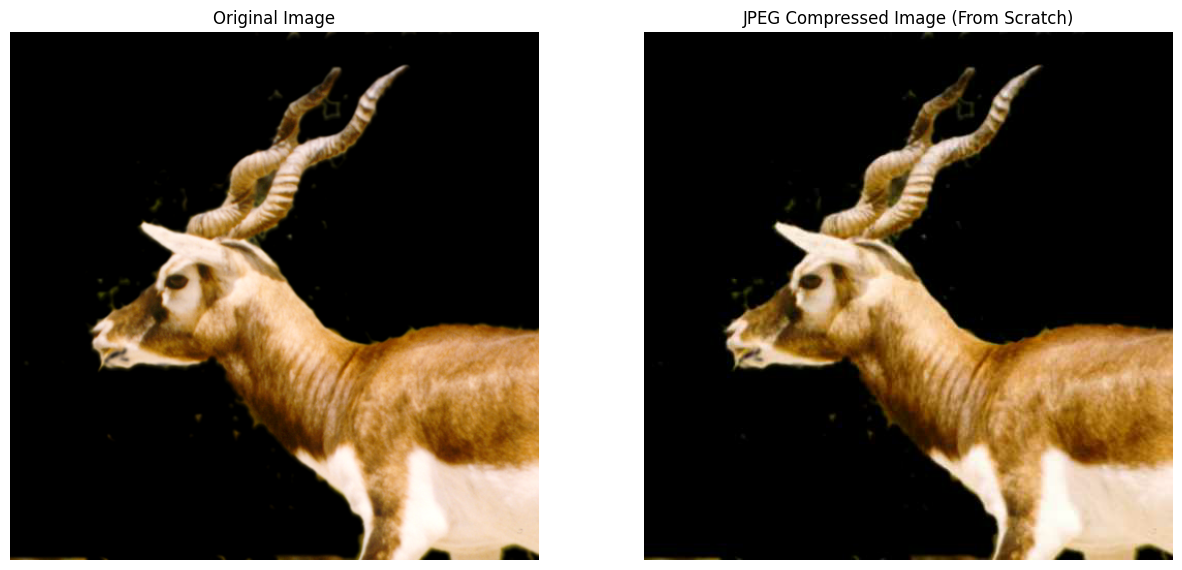

In [11]:
# Upsample Cb and Cr back to original Y dimensions
Cb_upsampled = np.kron(Cb_reconstructed, np.ones((2, 2)))
Cr_upsampled = np.kron(Cr_reconstructed, np.ones((2, 2)))

# Ensure upsampled dimensions match Y
Cb_upsampled = Cb_upsampled[:Y.shape[0], :Y.shape[1]]
Cr_upsampled = Cr_upsampled[:Y.shape[0], :Y.shape[1]]

# Combine channels
reconstructed_ycbcr_array = np.stack([Y_reconstructed, Cb_upsampled, Cr_upsampled], axis=-1)

# Clip values to 0-255 range and convert to uint8
reconstructed_ycbcr_array = np.clip(reconstructed_ycbcr_array, 0, 255).astype(np.uint8)

# Convert YCbCr back to RGB using PIL
compressed_img_pil = Image.fromarray(reconstructed_ycbcr_array, 'YCbCr').convert('RGB')

# Display original and compressed images
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(compressed_img_pil)
plt.title('JPEG Compressed Image (From Scratch)')
plt.axis('off')

plt.show()

### LSB Steganography: Hiding an Image in Another

This section demonstrates a basic implementation of Least Significant Bit (LSB) steganography to hide a grayscale 'secret' image within the LSB of a 'cover' grayscale image. The process involves:

1.  **Loading and Preprocessing**: Loading two images (cover and secret), converting them to grayscale, and ensuring they have compatible dimensions.
2.  **Hiding**: Modifying the LSB of each pixel in the cover image with the most significant bit of the corresponding secret image pixel.
3.  **Extraction**: Retrieving the LSBs from the steganographic (hidden) image to reconstruct the secret image.

In [12]:
# Load a secret image
secret_image_url = 'https://people.math.sc.edu/Burkardt/data/bmp/snail.bmp' # Using the same secret image as before
response_secret = requests.get(secret_image_url)
secret_image_data = response_secret.content
secret_img_pil = Image.open(BytesIO(secret_image_data)).convert('RGB') # Ensure secret is RGB

# Ensure cover image is RGB (if it's not already)
cover_pil = img.convert('RGB')

# Resize the secret image to match the cover image dimensions
secret_resized_pil = secret_img_pil.resize(cover_pil.size)

# Convert to numpy arrays
cover_np_color = np.array(cover_pil)
secret_np_color = np.array(secret_resized_pil)

print(f"Cover image shape: {cover_np_color.shape}")
print(f"Secret image shape: {secret_np_color.shape}")

Cover image shape: (512, 512, 3)
Secret image shape: (512, 512, 3)


In [13]:
def hide_image_lsb_color(cover, secret):
    # Ensure images are numpy arrays and have the same shape
    cover_np = np.array(cover)
    secret_np = np.array(secret)

    if cover_np.shape != secret_np.shape:
        raise ValueError("Cover and secret images must have the same dimensions for color LSB hiding.")

    stego_image_np = np.zeros_like(cover_np)

    for i in range(3): # Iterate through R, G, B channels
        cover_channel = cover_np[:, :, i]
        secret_channel = secret_np[:, :, i]

        # Clear the 2 LSBs of the cover image
        cover_cleared_lsbs = cover_channel & 0xFC  # Binary 11111100

        # Get the 2 MSBs of the secret channel and shift them to the LSB position
        secret_msbs = secret_channel >> 6

        # Combine them: replace the cover's 2 LSBs with the secret's 2 MSBs
        stego_image_np[:, :, i] = cover_cleared_lsbs | secret_msbs

    return Image.fromarray(stego_image_np.astype(np.uint8))

def extract_image_lsb_color(stego_image):
    stego_np = np.array(stego_image)
    extracted_secret_np = np.zeros_like(stego_np)

    for i in range(3): # Iterate through R, G, B channels
        stego_channel = stego_np[:, :, i]
        # Extract the 2 LSBs from the stego channel
        extracted_lsbs = stego_channel & 0x03  # Binary 00000011

        # Scale the extracted 2 bits back to a full 0-255 range for visibility
        # by shifting left by 6 positions
        extracted_secret_np[:, :, i] = extracted_lsbs << 6

    return Image.fromarray(extracted_secret_np.astype(np.uint8))

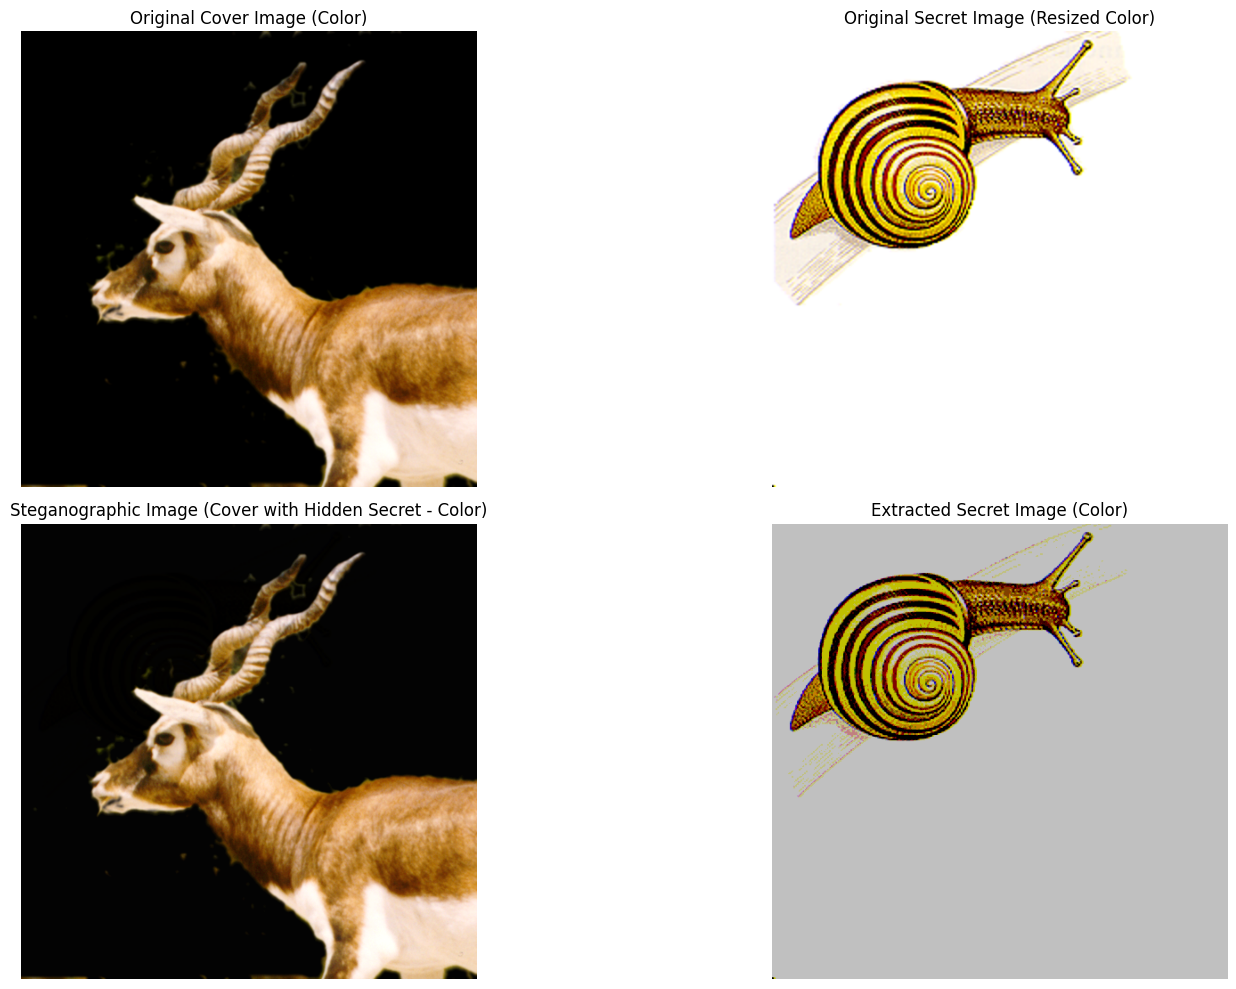

In [14]:
# Perform LSB hiding with color images
stego_image_color = hide_image_lsb_color(cover_np_color, secret_np_color)

# Perform LSB extraction with color images
extracted_secret_color = extract_image_lsb_color(stego_image_color)

# Display the results
plt.figure(figsize=(18, 10))

plt.subplot(2, 2, 1)
plt.imshow(cover_pil) # Display original color cover
plt.title('Original Cover Image (Color)')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(secret_resized_pil) # Display original color secret
plt.title('Original Secret Image (Resized Color)')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(stego_image_color)
plt.title('Steganographic Image (Cover with Hidden Secret - Color)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(extracted_secret_color)
plt.title('Extracted Secret Image (Color)')
plt.axis('off')

plt.tight_layout()
plt.show()

# SIFT

### Scale-Invariant Feature Transform (SIFT)

SIFT is a robust feature detection algorithm that can identify and describe local features in images, which are invariant to scale, rotation, and illumination changes. Here, we'll demonstrate its basic usage:

1.  **Convert to Grayscale**: SIFT typically operates on grayscale images.
2.  **Initialize SIFT Detector**: Create a SIFT object.
3.  **Detect Keypoints and Compute Descriptors**: Find distinctive points (keypoints) in the image and compute their associated descriptors.
4.  **Visualize Keypoints**: Draw the detected keypoints on the image.

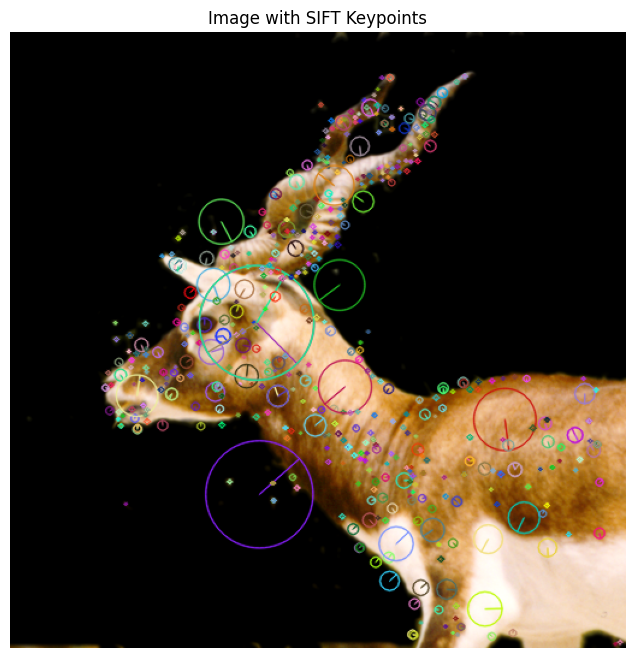

Keypoint 1: (78.79, 295.17) 5.258864402770996
Keypoint 2: (81.18, 282.74) 3.8227150440216064
Keypoint 3: (82.45, 314.31) 6.454667091369629
Keypoint 4: (83.67, 292.83) 3.5374488830566406
Keypoint 5: (87.14, 241.10) 2.501938581466675
Keypoint 6: (87.96, 254.94) 3.8168365955352783
Keypoint 7: (89.48, 321.28) 2.7833430767059326
Keypoint 8: (90.15, 273.99) 6.552901744842529
Keypoint 9: (90.19, 315.36) 4.616447925567627
Keypoint 10: (91.43, 284.64) 9.818949699401855
Keypoint 11: (91.53, 326.40) 3.4613049030303955
Keypoint 12: (91.84, 327.00) 3.952995777130127
Keypoint 13: (93.32, 318.60) 2.560760974884033
Keypoint 14: (95.74, 391.86) 2.094857931137085
Keypoint 15: (98.38, 264.96) 2.6041371822357178
Keypoint 16: (98.38, 264.96) 2.6041371822357178
Keypoint 17: (99.16, 251.56) 4.200518608093262
Keypoint 18: (99.16, 251.56) 4.200518608093262
Keypoint 19: (100.14, 278.24) 3.0009026527404785
Keypoint 20: (100.65, 272.20) 4.072486877441406
Keypoint 21: (100.97, 313.28) 4.574061870574951
Keypoint 22

In [15]:
import cv2 as cv

# Convert PIL image to OpenCV format (NumPy array)
# First, convert PIL RGB to NumPy array
img_cv = np.array(img)

# OpenCV uses BGR by default, so if PIL image is RGB, convert it
# Although, for grayscale conversion, it might not be strictly necessary
# if cv.cvtColor is used with COLOR_RGB2GRAY

# Convert to grayscale
def SIFT(img):
  img_cv = np.array(img)

  gray_cv = cv.cvtColor(img_cv, cv.COLOR_RGB2GRAY)

  # Create SIFT feature detector object
  sift = cv.SIFT_create()

  # Detect keypoints and compute descriptors
  keypoints, descriptors = sift.detectAndCompute(gray_cv, None)

  # Draw keypoints on the original image
  # The image needs to be converted back to BGR for drawing in color with OpenCV
  img_with_keypoints = cv.drawKeypoints(img_cv, keypoints, None, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

  # Convert back to PIL for display if desired
  img_with_keypoints_pil = Image.fromarray(img_with_keypoints)


  return img_with_keypoints_pil, keypoints, descriptors

img_with_keypoints,key,descriptors=  SIFT(img)
# Display the image with keypoints
plt.figure(figsize=(10, 8))
plt.imshow(img_with_keypoints)
plt.title('Image with SIFT Keypoints')
plt.axis('off')
plt.show()
for i, kp in enumerate(key[:]):
    print(f"Keypoint {i+1}: ({kp.pt[0]:.2f}, {kp.pt[1]:.2f}) {kp.size}")

### Image Perspective Transformation

This section demonstrates how to apply a perspective transformation to an image. This technique allows you to warp an image so that it appears to be on a surface viewed from an angle, often used to place an image realistically onto a screen or a wall in another photo.

In [16]:
def apply_perspective_transform(image_np, dest_points):
    """
    Applies a perspective transformation to an image.

    Args:
        image_np (np.array): The input image as a NumPy array (e.g., from OpenCV).
        dest_points (np.array): A 4x2 NumPy array of the destination corner points
                                (top-left, top-right, bottom-right, bottom-left) in the output image.

    Returns:
        np.array: The transformed image.
    """
    # Get image dimensions
    h, w = image_np.shape[:2]

    # Define source points (corners of the original image)
    src_points = np.float32([
        [0, 0],          # Top-left
        [w - 1, 0],      # Top-right
        [w - 1, h - 1],  # Bottom-right
        [0, h - 1]       # Bottom-left
    ])

    # Convert destination points to float32
    dest_points = np.float32(dest_points)

    # Get the perspective transformation matrix
    matrix = cv.getPerspectiveTransform(src_points, dest_points)

    # Determine the size of the output image based on destination points
    # For simplicity, we'll use the original image size, assuming the dest_points are within reasonable bounds.
    # For more advanced usage, one might calculate a bounding box for the warped image.
    output_width = w
    output_height = h

    # Apply the perspective transformation
    transformed_image = cv.warpPerspective(image_np, matrix, (output_width, output_height))

    return transformed_image

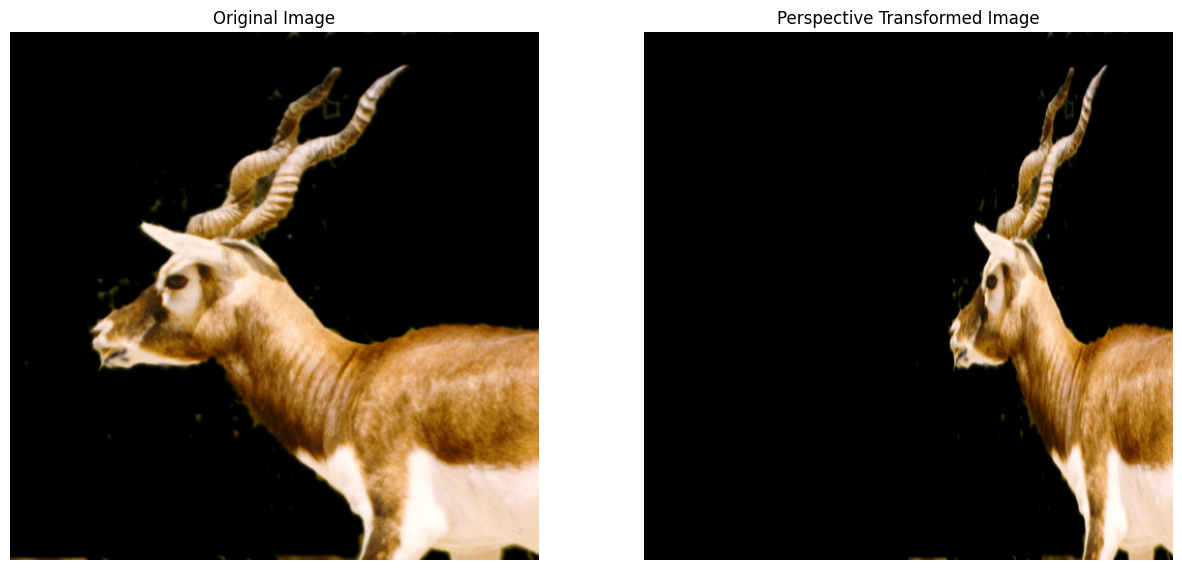

<Figure size 1500x700 with 0 Axes>

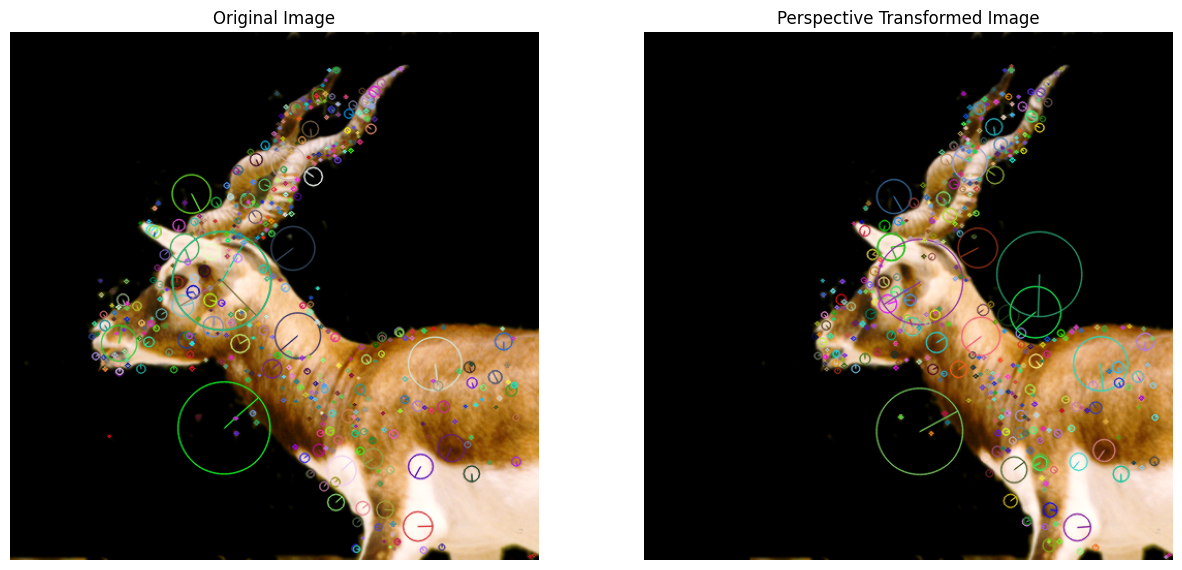

555 451


In [17]:
# Reuse the original image 'img' and its OpenCV numpy array 'img_cv'
# If you want to use a different image, load it here.

# Define the destination points for the perspective transform.
# These points create a simple skewed 'screen' effect.
# You can modify these to fit a specific background or perspective.

# Example: A slight tilt to the right and top, making it look like a screen viewed at an angle
# (top-left, top-right, bottom-right, bottom-left)

# Adjusting destination points relative to the image size for demonstration
#x,y
#[0,0]
#top to bottom 0 to h-1
#left to right 0 to w-1
h, w = img_cv.shape[:2]
dest_points = np.array([
    [w*.5, 0],          # Top-left
    [w - 1, 0],      # Top-right
    [w - 1, h - 1],  # Bottom-right
    [w*.5, h - 1]       # Bottom-left
])

# Apply the transformation
transformed_img_cv = apply_perspective_transform(img_cv, dest_points)

# Convert the transformed OpenCV image back to PIL for display
transformed_img_pil =np.array( Image.fromarray(transformed_img_cv))

# Display the original and transformed images
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(transformed_img_pil)
plt.title('Perspective Transformed Image')
plt.axis('off')

h, w = transformed_img_pil.shape[:2]
dest_points = np.array([
    [-w*0.6, 0],          # Top-left
    [w - 1, 0],      # Top-right
    [w - 1, h - 1],  # Bottom-right
    [-w*0.6, h - 1]       # Bottom-left
])

# Apply the transformation
transformed_img_cv2 = apply_perspective_transform(transformed_img_pil, dest_points)

# Convert the transformed OpenCV image back to PIL for display
transformed_img_pil = Image.fromarray(transformed_img_cv2)

# Display the original and transformed images
plt.figure(figsize=(15, 7))
plt.show()
i1,key1,d1=SIFT(img)
i2,key2,d2=SIFT(transformed_img_pil)
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(i1)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(i2)
plt.title('Perspective Transformed Image')
plt.axis('off')
plt.show()

print(len(key1),len(key2))

In [18]:

# Initialize a Brute-Force Matcher
bf = cv.BFMatcher(cv.NORM_L2, crossCheck=True) # NORM_L2 for SIFT, crossCheck=True ensures best matches in both directions

# Match descriptors
matches = bf.match(d1, d2)

# Sort matches by distance (smaller distance means better match)
matches = sorted(matches, key = lambda x:x.distance)

print("Top 10 closest keypoint matches:")
for i, match in enumerate(matches[:10]):
    # Get the keypoints from the match
    kp1 = key1[match.queryIdx] # Keypoint from the first image (key1)
    kp2 = key2[match.trainIdx] # Keypoint from the second image (key2)

    print(f"Match {i+1}:")
    print(f"  Keypoint 1 (Original): (x={kp1.pt[0]:.2f}, y={kp1.pt[1]:.2f}) - size: {kp1.size:.2f}")
    print(f"  Keypoint 2 (Transformed): (x={kp2.pt[0]:.2f}, y={kp2.pt[1]:.2f}) - size: {kp2.size:.2f}")
    print(f"  Distance: {match.distance:.2f}")

Top 10 closest keypoint matches:
Match 1:
  Keypoint 1 (Original): (x=418.99, y=286.19) - size: 3.90
  Keypoint 2 (Transformed): (x=438.03, y=286.25) - size: 3.95
  Distance: 28.12
Match 2:
  Keypoint 1 (Original): (x=307.35, y=289.60) - size: 3.27
  Keypoint 2 (Transformed): (x=348.45, y=289.73) - size: 3.30
  Distance: 41.88
Match 3:
  Keypoint 1 (Original): (x=376.77, y=291.56) - size: 6.87
  Keypoint 2 (Transformed): (x=403.13, y=291.84) - size: 6.38
  Distance: 42.15
Match 4:
  Keypoint 1 (Original): (x=486.66, y=296.97) - size: 3.29
  Keypoint 2 (Transformed): (x=491.70, y=296.91) - size: 3.15
  Distance: 42.65
Match 5:
  Keypoint 1 (Original): (x=428.92, y=287.62) - size: 5.11
  Keypoint 2 (Transformed): (x=445.25, y=287.68) - size: 5.14
  Distance: 43.34
Match 6:
  Keypoint 1 (Original): (x=126.42, y=326.51) - size: 8.33
  Keypoint 2 (Transformed): (x=204.40, y=326.34) - size: 7.74
  Distance: 49.98
Match 7:
  Keypoint 1 (Original): (x=246.63, y=110.21) - size: 8.11
  Keypoint 

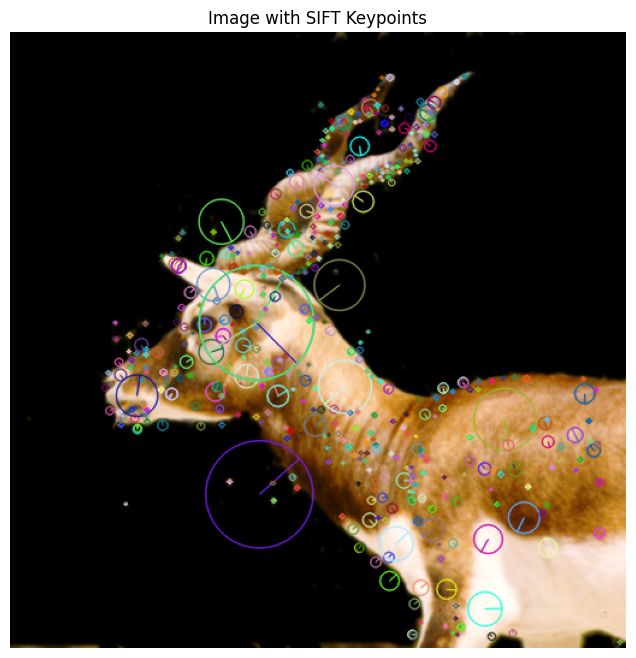

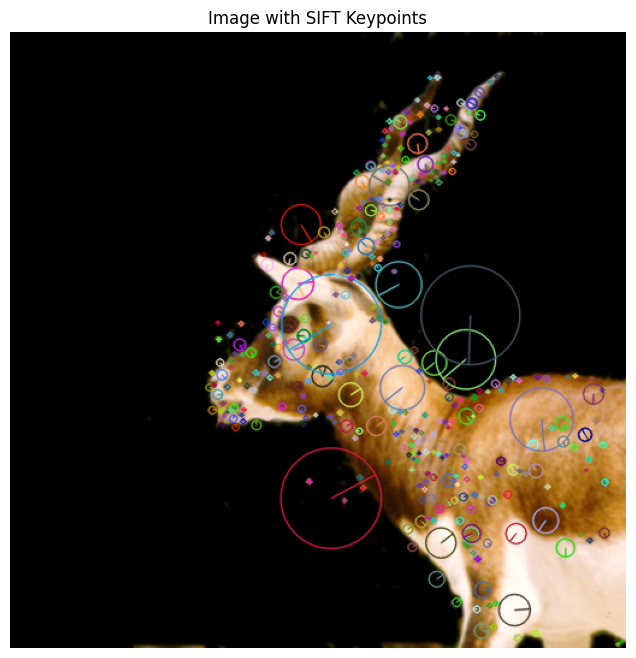

555 451


In [19]:

def displayISIFT(img):
    img_cv = np.array(img)
    gray_cv = cv.cvtColor(img_cv, cv.COLOR_RGB2GRAY)

    # 1. Create SIFT detector
    sift = cv.SIFT_create()

    # 2. Detect keypoints (We don't need compute() for the 128-D descriptors)
    keypoints = sift.detect(gray_cv, None)

    # 3. Extract Intensities (The "Intensity-Based" modification)
    # We loop through keypoints and grab the pixel value from the gray image
    i_sift_data = []
    for kp in keypoints:
        x, y = int(kp.pt[0]), int(kp.pt[1])
        intensity = gray_cv[y, x] # Extracting the raw intensity value
        i_sift_data.append((kp, intensity))

    # 4. Draw keypoints for visualization
    # Note: I-SIFT usually implies using these intensities for blind extraction
    # rather than standard matching.
    img_with_keypoints = cv.drawKeypoints(
        img_cv,
        keypoints,
        None,
        flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )

    # Convert back to PIL for display
    img_with_keypoints_pil = Image.fromarray(img_with_keypoints)

    plt.figure(figsize=(10, 8))
    plt.imshow(img_with_keypoints_pil)
    plt.title('Image with SIFT Keypoints')
    plt.axis('off')
    plt.show()

    return keypoints, i_sift_data

k1,ishi1 =displayISIFT(img)
k2,ishi2 = displayISIFT(transformed_img_pil)

print(len(k1),len(k2))

In [20]:
# Convert to grayscale
def displaySIFT(img):
  img_cv = np.array(img)

  gray_cv = cv.cvtColor(img_cv, cv.COLOR_RGB2GRAY)

  # Create SIFT feature detector object
  sift = cv.SIFT_create()

  # Detect keypoints and compute descriptors
  keypoints, descriptors = sift.detectAndCompute(gray_cv, None)

  # Draw keypoints on the original image
  # The image needs to be converted back to BGR for drawing in color with OpenCV
  img_with_keypoints = cv.drawKeypoints(img_cv, keypoints, None, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

  # Convert back to PIL for display if desired
  img_with_keypoints_pil = Image.fromarray(img_with_keypoints)

  # Display the image with keypoints
  plt.figure(figsize=(10, 8))
  plt.imshow(img_with_keypoints_pil)
  plt.title('Image with SIFT Keypoints')
  plt.axis('off')
  plt.show()
  return keypoints, descriptors

# MD5 Hashing a String

MD5 (Message-Digest Algorithm 5) is a widely used cryptographic hash function that produces a 128-bit (16-byte) hash value. It's commonly used to verify data integrity.

In [21]:
import hashlib

# Define the string to be hashed
input_string = "Hello, Colab! This is a test string for MD5 hashing."

# Encode the string to bytes (UTF-8 is common)
encoded_string = input_string.encode('utf-8')

# Create an MD5 hash object
md5_hash_object = hashlib.md5()

# Update the hash object with the encoded string
md5_hash_object.update(encoded_string)

# Get the hexadecimal representation of the hash
hex_dig = md5_hash_object.hexdigest()

# Get the byte representation of the hash
byte_dig = md5_hash_object.digest()

print(f"Original String: '{input_string}'")
print(f"MD5 Hash (Hex): {hex_dig}")

# Split the hexadecimal hash into pairs of characters
hex_pairs = [hex_dig[i:i+2] for i in range(0, len(hex_dig), 2)]
print(f"MD5 Hash (Hex Pairs): {hex_pairs}")

Original String: 'Hello, Colab! This is a test string for MD5 hashing.'
MD5 Hash (Hex): 5261a7190bfd0f4a886313ac9aa35db8
MD5 Hash (Hex Pairs): ['52', '61', 'a7', '19', '0b', 'fd', '0f', '4a', '88', '63', '13', 'ac', '9a', 'a3', '5d', 'b8']


Original MD5 Binary (128 bits): 01010010011000011010011100011001000010111111110100001111010010101000100001100011000100111010110010011010101000110101110110111000
Encoded MD5 Binary (224 bits): 01001010101010110011011010011011010000111111010010011001000000001100111111111101010100000001111111100110010110101110000111000011001101000011110100110000111011010011110000110011011010101101010000110100101101010101100111110000
Original length: 128 bits
Encoded length: 224 bits (Expected: 224.0 bits)


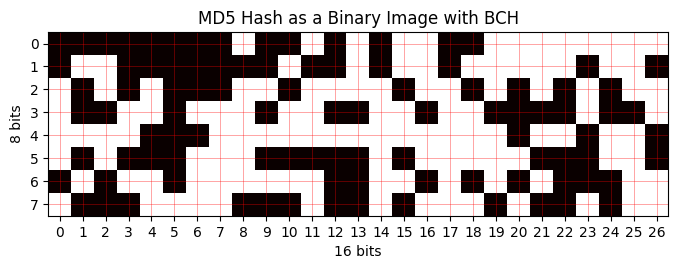

In [22]:
def hex_to_binary(hex_string):
    """
    Converts a hexadecimal string to its binary representation.
    Each hex digit becomes 4 binary digits.
    """
    return bin(int(hex_string, 16))[2:].zfill(len(hex_string) * 4)

def hamming_encode_4_bit(data):
    """
    Encodes 4 data bits (d1, d2, d3, d4) into a 7-bit Hamming codeword (p1, p2, d1, p3, d2, d3, d4).
    Parity bits are calculated as follows:
    p1 = d1 ^ d2 ^ d4
    p2 = d1 ^ d3 ^ d4
    p3 = d2 ^ d3 ^ d4
    """
    if len(data) != 4 or not all(c in '01' for c in data):
        raise ValueError("Input data must be a 4-bit binary string.")

    d1, d2, d3, d4 = map(int, list(data))

    p1 = d1 ^ d2 ^ d4
    p2 = d1 ^ d3 ^ d4
    p3 = d2 ^ d3 ^ d4

    # Codeword format: p1 p2 d1 p3 d2 d3 d4
    codeword = f"{p1}{p2}{d1}{p3}{d2}{d3}{d4}"
    return codeword

# Get the hex_dig from the previous cell's execution
# hex_dig = '5261a7190bfd0f4a886313ac9aa35db8' # Example if not already in scope

# Convert hex_dig to a 128-bit binary string
binary_md5 = hex_to_binary(hex_dig)
print(f"Original MD5 Binary ({len(binary_md5)} bits): {binary_md5}")

# Split the binary_md5 into 4-bit chunks and encode each chunk
encoded_binary_chunks = []
for i in range(0, len(binary_md5), 4):
    chunk = binary_md5[i : i + 4]
    if len(chunk) == 4:
        encoded_chunk = hamming_encode_4_bit(chunk)
        encoded_binary_chunks.append(encoded_chunk)
    else:
        # Handle cases where the last chunk might be less than 4 bits if not padded
        # For MD5 (128 bits), it will always be perfectly divisible by 4.
        pass

encoded_md5 = "".join(encoded_binary_chunks)

print(f"Encoded MD5 Binary ({len(encoded_md5)} bits): {encoded_md5}")
print(f"Original length: {len(binary_md5)} bits")
print(f"Encoded length: {len(encoded_md5)} bits (Expected: {len(binary_md5)/4 * 7} bits)")

new = []
for i in hex_to_binary("0x959fec04b7daa37b55cdd9b09f1fff6d4705f196fcd51c78974b"):
  new.append(int(i))
image_array_bits = np.array(new).reshape((8, 27))
# Display the image
plt.figure(figsize=(8, 4))
plt.imshow(image_array_bits, cmap='hot', vmin=0)
plt.title('MD5 Hash as a Binary Image with BCH')
plt.xlabel('16 bits')
plt.ylabel('8 bits')
plt.xticks(np.arange(27))
plt.yticks(np.arange(8))
plt.grid(True, color='red', linewidth=0.5, alpha=0.5)
plt.show()

In [23]:
pip install reedsolo

### BCH Error Correction with `reedsolo`

This section demonstrates BCH error correction using the `reedsolo` library. It uses a similar workflow to the `bchlib` example, generating an MD5 hash, encoding it, simulating a bit error, and then attempting to correct it.

In [24]:
from reedsolo import RSCodec, ReedSolomonError
import hashlib

# 1. Configuration for reedsolo (Example parameters)
# nsym: number of error correction symbols (parity bytes)
# We'll use a larger block size for RS codes, which operate on bytes.
# Let's say we want to correct up to 't' errors. reedsolo requires nsym = 2*t
# For simplicity, let's aim for a fixed number of parity bytes for now.
NSYM = 10 # Number of syndrome bytes (parity bytes)

# 2. Generate the MD5 Hash
md5_data_rs = "Hello World with reedsolo"
hash_obj_rs = hashlib.md5(md5_data_rs.encode())
hash_bytes_rs = hash_obj_rs.digest()  # 16 bytes (128 bits)
print(f"Original MD5 (Hex): {hash_obj_rs.hexdigest()}")
print(f"Original MD5 Length: {len(hash_bytes_rs)} bytes")

# 3. Initialize RSCodec
# RSCodec(nsym, nsize=255, c_exp=8) will create an RS codec for a given number of parity symbols.
# nsize is the block size (default 255 for GF(2^8)). Message + Parity should not exceed nsize.
# Let's create an RS codec suitable for our 16-byte hash + NSYM parity bytes
# The maximum total block length (message + parity) should be <= 255 for GF(2^8).

# Ensure our total message size doesn't exceed 255 if nsym is small.
# Our message length is 16 bytes. If nsym=10, total length = 26 bytes, which is fine.
rs = RSCodec(NSYM)

# 4. Apply RS Encoding (Calculate Parity and append)
# encode() function expects a byte array and returns an encoded byte array
encoded_packet_rs = rs.encode(bytearray(hash_bytes_rs))

print(f"Encoded Packet Length: {len(encoded_packet_rs)} bytes")
print(f"Encoded Packet (Hex): {encoded_packet_rs.hex()}")

# --- Demonstration of Error Correction ---

# Introduce a simulated error (flip a bit in one byte)
corrupted_packet_rs = bytearray(encoded_packet_rs)
# Flip a bit in the first byte (index 0)
corrupted_packet_rs[0] ^= 0x01 # Flip the LSB of the first byte

print(f"Corrupted Packet (Hex): {corrupted_packet_rs.hex()}")

# 5. Decode and Correct
# decode() returns (decoded_data, number_of_errors_corrected, erasure_locations)
try:
    decoded_data_rs, n_err_rs_count, _ = rs.decode(corrupted_packet_rs)

    if isinstance(n_err_rs_count, int) and n_err_rs_count >= 0:
        print(f"\nSuccess: Corrected {n_err_rs_count} error(s).")
        # decoded_data_rs contains the original message bytes
        recovered_hash_bytes_rs = bytes(decoded_data_rs)
        print(f"Recovered Hash (Hex): {recovered_hash_bytes_rs.hex()}")

        if recovered_hash_bytes_rs == hash_bytes_rs:
            print("Recovery successful: The original hash matches the recovered hash.")
        else:
            print("Recovery failed: The original hash DOES NOT match the recovered hash.")
    else:
        # This branch should ideally not be reached if ReedSolomonError is caught correctly,
        # but it handles the specific TypeError if n_err_rs_count is not an int.
        print(f"\nFailure: Could not correct errors (unexpected error count value type: {type(n_err_rs_count)}, value: {n_err_rs_count}).")

except ReedSolomonError as e:
    print(f"\nFailure: Could not correct errors (too many errors detected or uncorrectable by RSCodec): {e}")
except Exception as e:
    print(f"\nAn unexpected error occurred during decoding: {e}")


Original MD5 (Hex): 959fec04b7daa37b55cdd9b09f1fff6d
Original MD5 Length: 16 bytes
Encoded Packet Length: 26 bytes
Encoded Packet (Hex): 959fec04b7daa37b55cdd9b09f1fff6d4705f196fcd51c78974b
Corrupted Packet (Hex): 949fec04b7daa37b55cdd9b09f1fff6d4705f196fcd51c78974b

Failure: Could not correct errors (unexpected error count value type: <class 'bytearray'>, value: bytearray(b'\x95\x9f\xec\x04\xb7\xda\xa3{U\xcd\xd9\xb0\x9f\x1f\xffmG\x05\xf1\x96\xfc\xd5\x1cx\x97K')).


In [25]:
hashmap = {}
for i in hex_pairs:
  hashmap[i] = hashmap.get(i, 0) + 1
  print(i[0],int("0x"+i[0],16) ,int("0x"+i[0],16)%8 )

print(hashmap)

5 5 5
6 6 6
a 10 2
1 1 1
0 0 0
f 15 7
0 0 0
4 4 4
8 8 0
6 6 6
1 1 1
a 10 2
9 9 1
a 10 2
5 5 5
b 11 3
{'52': 1, '61': 1, 'a7': 1, '19': 1, '0b': 1, 'fd': 1, '0f': 1, '4a': 1, '88': 1, '63': 1, '13': 1, 'ac': 1, '9a': 1, 'a3': 1, '5d': 1, 'b8': 1}


In [26]:
import string
import random
def generate_random_string(length):
    # Combine letters and digits
    characters = string.ascii_letters + string.digits
    # Select 'length' characters randomly
    return ''.join(random.choices(characters, k=length))

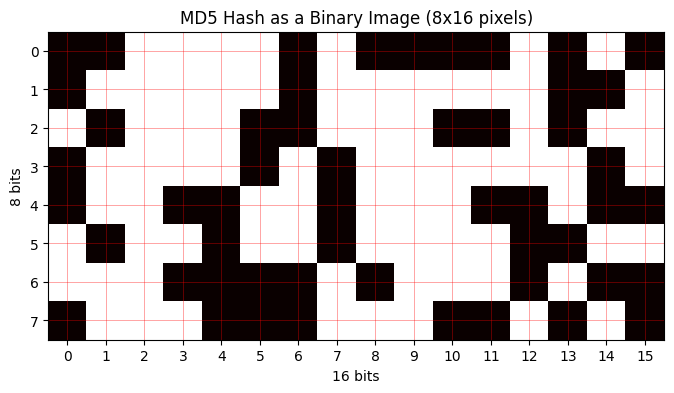

In [27]:
Heatmap = np.zeros(128)


for i in range(1):
  input_string = generate_random_string(10)

  encoded_string = input_string.encode('utf-8')

  md5_hash_object = hashlib.md5()

  md5_hash_object.update(encoded_string)

  hex_dig = md5_hash_object.hexdigest()
  # Convert hex_dig to a 128-bit binary string
  binary_string = bin(int(hex_dig, 16))[2:].zfill(128)
  Heatmap += np.array([int(bit) for bit in binary_string])
  # Convert the binary string into a NumPy array of bits (0s and 1s)
  bit_array = np.array([int(bit) for bit in binary_string])

  # Reshape the 128 bits into an 8x16 image array
  # 8 * 16 = 128
  image_array_bits = bit_array.reshape((8, 16))
Heatmap_array_bits = Heatmap.reshape((8, 16))
# Display the image
plt.figure(figsize=(8, 4))
plt.imshow(Heatmap_array_bits, cmap='hot', vmin=0)
plt.title('MD5 Hash as a Binary Image (8x16 pixels)')
plt.xlabel('16 bits')
plt.ylabel('8 bits')
plt.xticks(np.arange(16))
plt.yticks(np.arange(8))
plt.grid(True, color='red', linewidth=0.5, alpha=0.5)
plt.show()

# start

In [28]:
def modify_n_lsbs_int(original_int, n_lsbs, new_lsbs_value):
    """
    Modifies the 'n_lsbs' least significant bits of an integer.

    Args:
        original_int (int): The integer whose LSBs are to be modified.
        n_lsbs (int): The number of least significant bits to modify (e.g., 1, 2, 3).
        new_lsbs_value (int): The new value for the 'n_lsbs'. This value should be
                              representable within 'n_lsbs' bits (i.e., 0 <= new_lsbs_value < 2**n_lsbs).

    Returns:
        int: The integer with modified LSBs.
    """
    if not (1 <= n_lsbs <= 63): # Python ints can be arbitrary size, but typically for LSBs up to 63 is practical
        raise ValueError("n_lsbs must be between 1 and 63 for practical use.")
    if not (0 <= new_lsbs_value < (1 << n_lsbs)):
        raise ValueError(f"new_lsbs_value ({new_lsbs_value}) must be representable within {n_lsbs} bits (0 to {(1 << n_lsbs) - 1})")

    # Create a mask to clear the n_lsbs
    # Example: if n_lsbs=2, mask_clear_value = 0b...11111100
    mask_clear_value = ~((1 << n_lsbs) - 1)

    # Clear the n_lsbs of the original_int
    cleared_lsbs_int = original_int & mask_clear_value

    # Set the new n_lsbs
    modified_int = cleared_lsbs_int | new_lsbs_value

    return modified_int

# --- Demonstration ---
original_number = 173  # Binary: 10101101
print(f"Original Number: {original_number} (Binary: {bin(original_number)})")

n_bits = 3
new_value = 0b010  # Binary: 010 (decimal 2)
# Expected: 10101101 -> clear last 3 bits (10101000) -> add 010 (10101010) -> 170

modified_number = modify_n_lsbs_int(original_number, n_bits, new_value)
print(f"Modified Number (n_lsbs={n_bits}, new_value={new_value}): {modified_number} (Binary: {bin(modified_number)})")

n_bits_2 = 4
new_value_2 = 0b1111 # Binary: 1111 (decimal 15)
# Expected: 10101101 -> clear last 4 bits (10100000) -> add 1111 (10101111) -> 175

modified_number_2 = modify_n_lsbs_int(original_number, n_bits_2, new_value_2)
print(f"Modified Number (n_lsbs={n_bits_2}, new_value={new_value_2}): {modified_number_2} (Binary: {bin(modified_number_2)})")

Original Number: 173 (Binary: 0b10101101)
Modified Number (n_lsbs=3, new_value=2): 170 (Binary: 0b10101010)
Modified Number (n_lsbs=4, new_value=15): 175 (Binary: 0b10101111)


In [29]:
def preprocess(img):

  # The ycbcr_img from previous steps is a PIL Image. Convert it to a numpy array for processing.
  ycbcr_array = np.array(img.convert('YCbCr'))

  # Separate Y, Cb, Cr channels
  Y = ycbcr_array[:, :, 0]
  Cb = ycbcr_array[:, :, 1]
  Cr = ycbcr_array[:, :, 2]

  print(f"Original Y shape: {Y.shape}")
  print(f"Original Cb shape: {Cb.shape}")
  print(f"Original Cr shape: {Cr.shape}")

  # Simple 4:2:0 subsampling (average 2x2 blocks)
  Cb_subsampled = Cb.reshape(Cb.shape[0] // 2, 2, Cb.shape[1] // 2, 2).mean(axis=(1, 3))
  Cr_subsampled = Cr.reshape(Cr.shape[0] // 2, 2, Cr.shape[1] // 2, 2).mean(axis=(1, 3))
  return Y,Cb_subsampled,Cr_subsampled



In [128]:
c=[(7,7),(6,6)]

Original Y shape: (512, 512)
Original Cb shape: (512, 512)
Original Cr shape: (512, 512)
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0

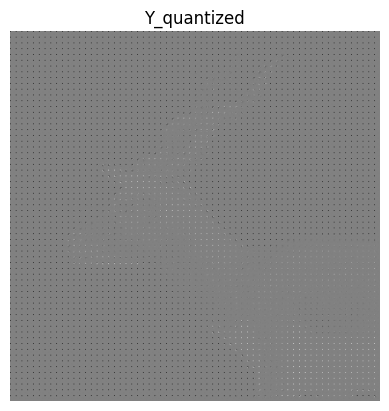

"\nplt.imshow(Cb_quantized,cmap=plt.cm.gray)\nplt.title('Cb_quantized')\nplt.axis('off')\nplt.show()\n\nplt.imshow(Cr_quantized,cmap=plt.cm.gray)\nplt.title('Cr_quantized')\nplt.axis('off')\nplt.show()\n"

In [123]:
# Define quantization matrices (example values for luminance and chrominance)
# These are simplified for demonstration; actual JPEG uses standard tables.

# Luminance Quantization Matrix (Q_Y)
Q_Y = np.array([
    [16, 11, 10, 16, 24, 40, 51, 61],
    [12, 12, 14, 19, 26, 58, 60, 55],
    [14, 13, 16, 24, 40, 57, 69, 56],
    [14, 17, 22, 29, 51, 87, 80, 62],
    [18, 22, 37, 56, 68, 109, 103, 77],
    [24, 35, 55, 64, 81, 104, 113, 92],
    [49, 64, 78, 87, 103, 121, 120, 101],
    [72, 92, 95, 98, 112, 100, 103, 99]
])

# Chrominance Quantization Matrix (Q_C)
Q_C = np.array([
    [17, 18, 24, 47, 99, 99, 99, 99],
    [18, 21, 26, 66, 99, 99, 99, 99],
    [24, 26, 40, 66, 99, 99, 99, 99],
    [47, 66, 66, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99]
])

def apply_dct_quantization(channel, Q_matrix,mes=False,writeBit=0):
    # Ensure the channel dimensions are multiples of 8
    h, w = channel.shape
    h_padded, w_padded = int(np.ceil(h/8)*8), int(np.ceil(w/8)*8)
    padded_channel = np.zeros((h_padded, w_padded))
    padded_channel[:h, :w] = channel

    quantized_coeffs = np.zeros_like(padded_channel)
    count =0
    for i in range(0, h_padded, 8):
        for j in range(0, w_padded, 8):
            block = padded_channel[i:i+8, j:j+8].astype(np.float32) - 128 # Subtract 128 for DCT
            dct_coeffs = dct(dct(block.T, norm='ortho').T, norm='ortho') # 2D DCT
            quantized_block = np.round(dct_coeffs / Q_matrix) # Quantization
            #writeBit = count%2
            #count+=1

            if(mes):

              #c=[(4,5),(5,4)]
              C1 = quantized_block[c[0][0]][c[0][1]]
              C2 = quantized_block[c[1][0]][c[1][1]]
              if(C1 ==C2):
                d=2
              else:
                d=abs(C1-C2)+1

              if(writeBit==0):
                quantized_block[c[0][0]][c[0][1]] = max(C1,C2)+d/2
                quantized_block[c[0][0]][c[0][1]] = min(C1,C2)-d/2
              else:
                quantized_block[c[1][0]][c[1][1]] = min(C1,C2)+d/2
                quantized_block[c[1][0]][c[1][1]] = max(C1,C2)-d/2
              print(writeBit)




            quantized_coeffs[i:i+8, j:j+8] = quantized_block


    return quantized_coeffs, h, w # Return original dimensions for later cropping

Y,Cb_subsampled,Cr_subsampled = preprocess(img)
Y_quantized, Y_h, Y_w = apply_dct_quantization(Y, Q_Y,True)
Cb_quantized, Cb_h, Cb_w = apply_dct_quantization(Cb_subsampled, Q_C)
Cr_quantized, Cr_h, Cr_w = apply_dct_quantization(Cr_subsampled, Q_C)


plt.imshow(Y_quantized,cmap=plt.cm.gray)
plt.title('Y_quantized')
plt.axis('off')
plt.show()
"""
plt.imshow(Cb_quantized,cmap=plt.cm.gray)
plt.title('Cb_quantized')
plt.axis('off')
plt.show()

plt.imshow(Cr_quantized,cmap=plt.cm.gray)
plt.title('Cr_quantized')
plt.axis('off')
plt.show()
"""

In [131]:
def apply_idct_dequantization(quantized_coeffs, Q_matrix, original_h, original_w,mes=False):
    h_padded, w_padded = quantized_coeffs.shape
    reconstructed_channel = np.zeros_like(quantized_coeffs, dtype=np.float32)

    for i in range(0, h_padded, 8):
        for j in range(0, w_padded, 8):
            quantized_block = quantized_coeffs[i:i+8, j:j+8]
            if(mes):
              C1 = quantized_block[c[0][0]][c[0][1]]
              C2 = quantized_block[c[1][0]][c[1][1]]
              if(C1<=C2):
                print(0)
              else:
                print(1)
            dequantized_block = quantized_block * Q_matrix # Dequantization
            idct_block = idct(idct(dequantized_block.T, norm='ortho').T, norm='ortho') # 2D IDCT
            reconstructed_block = idct_block + 128 # Add 128 back
            reconstructed_channel[i:i+8, j:j+8] = reconstructed_block

    # Crop back to original dimensions
    return reconstructed_channel[:original_h, :original_w]

Original Y shape: (512, 512)
Original Cb shape: (512, 512)
Original Cr shape: (512, 512)
Subsampled Cb shape: (256, 256)
Subsampled Cr shape: (256, 256)


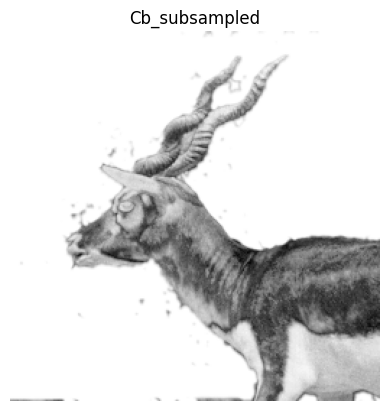

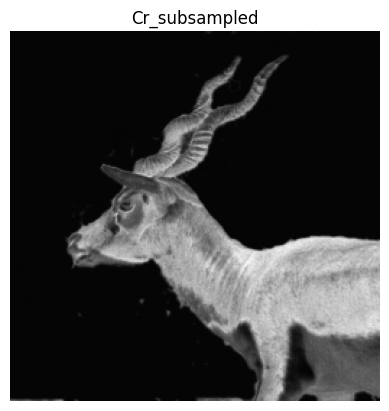

1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


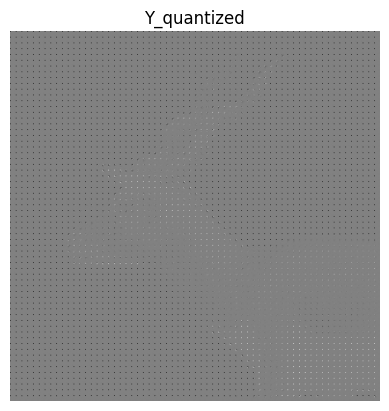

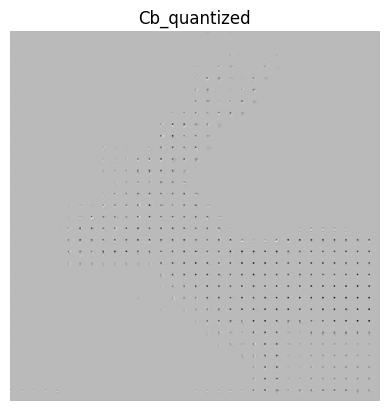

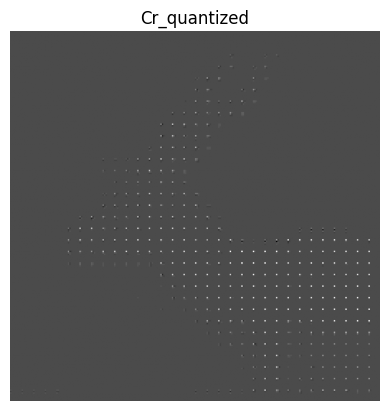

DCT and Quantization applied.
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


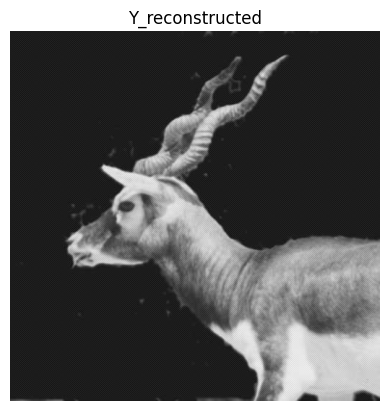

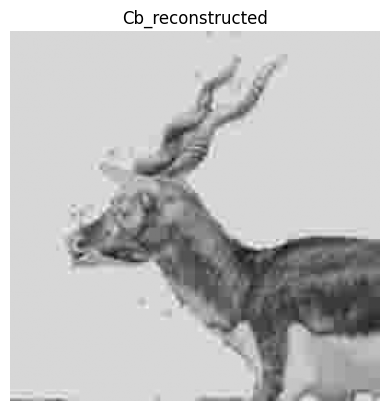

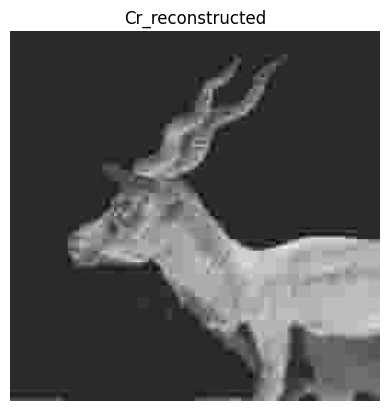

Dequantization and IDCT applied.


/tmp/ipykernel_2476/2192871752.py:75: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  compressed_img_pil = Image.fromarray(reconstructed_ycbcr_array, 'YCbCr').convert('RGB')


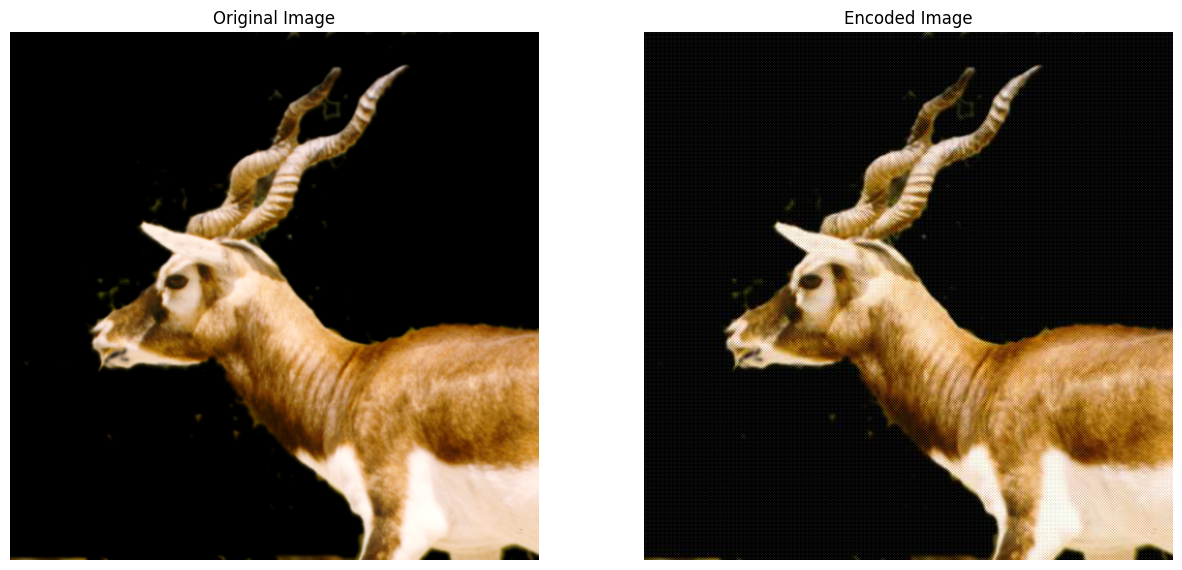

In [133]:
Y,Cb_subsampled,Cr_subsampled = preprocess(img)


print(f"Subsampled Cb shape: {Cb_subsampled.shape}")
print(f"Subsampled Cr shape: {Cr_subsampled.shape}")
plt.imshow(Cb_subsampled,cmap=plt.cm.gray)
plt.title('Cb_subsampled')
plt.axis('off')
plt.show()
plt.imshow(Cr_subsampled,cmap=plt.cm.gray)
plt.title('Cr_subsampled')
plt.axis('off')
plt.show()


# Apply to Y, Cb, Cr
Y_quantized, Y_h, Y_w = apply_dct_quantization(Y, Q_Y,True,1)
Cb_quantized, Cb_h, Cb_w = apply_dct_quantization(Cb_subsampled, Q_C)
Cr_quantized, Cr_h, Cr_w = apply_dct_quantization(Cr_subsampled, Q_C)


plt.imshow(Y_quantized,cmap=plt.cm.gray)
plt.title('Y_quantized')
plt.axis('off')
plt.show()

plt.imshow(Cb_quantized,cmap=plt.cm.gray)
plt.title('Cb_quantized')
plt.axis('off')
plt.show()

plt.imshow(Cr_quantized,cmap=plt.cm.gray)
plt.title('Cr_quantized')
plt.axis('off')
plt.show()
print("DCT and Quantization applied.")

# Apply to all channels
Y_reconstructed = apply_idct_dequantization(Y_quantized, Q_Y, Y_h, Y_w,True)
Cb_reconstructed = apply_idct_dequantization(Cb_quantized, Q_C, Cb_h, Cb_w)
Cr_reconstructed = apply_idct_dequantization(Cr_quantized, Q_C, Cr_h, Cr_w)


plt.imshow(Y_reconstructed,cmap=plt.cm.gray)
plt.title('Y_reconstructed')
plt.axis('off')
plt.show()

plt.imshow(Cb_reconstructed,cmap=plt.cm.gray)
plt.title('Cb_reconstructed')
plt.axis('off')
plt.show()

plt.imshow(Cr_reconstructed,cmap=plt.cm.gray)
plt.title('Cr_reconstructed')
plt.axis('off')
plt.show()
print("Dequantization and IDCT applied.")

# Upsample Cb and Cr back to original Y dimensions
Cb_upsampled = np.kron(Cb_reconstructed, np.ones((2, 2)))
Cr_upsampled = np.kron(Cr_reconstructed, np.ones((2, 2)))

# Ensure upsampled dimensions match Y
Cb_upsampled = Cb_upsampled[:Y.shape[0], :Y.shape[1]]
Cr_upsampled = Cr_upsampled[:Y.shape[0], :Y.shape[1]]

# Combine channels
reconstructed_ycbcr_array = np.stack([Y_reconstructed, Cb_upsampled, Cr_upsampled], axis=-1)

# Clip values to 0-255 range and convert to uint8
reconstructed_ycbcr_array = np.clip(reconstructed_ycbcr_array, 0, 255).astype(np.uint8)

# Convert YCbCr back to RGB using PIL
compressed_img_pil = Image.fromarray(reconstructed_ycbcr_array, 'YCbCr').convert('RGB')

# Display original and compressed images
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(compressed_img_pil)
plt.title('Encoded Image')
plt.axis('off')

plt.show()

Original Y shape: (512, 512)
Original Cb shape: (512, 512)
Original Cr shape: (512, 512)
Subsampled Cb shape: (256, 256)
Subsampled Cr shape: (256, 256)
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0

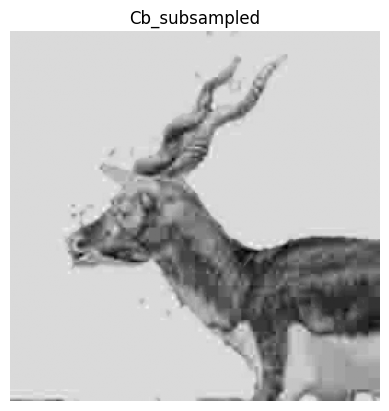

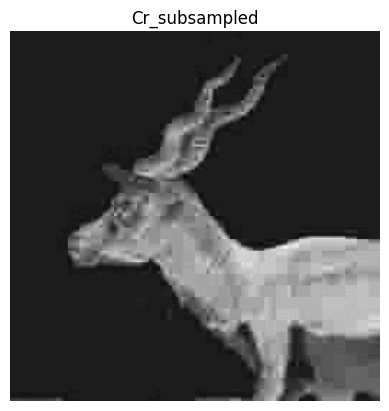

In [76]:
Y,Cb_subsampled,Cr_subsampled = preprocess(compressed_img_pil)


print(f"Subsampled Cb shape: {Cb_subsampled.shape}")
print(f"Subsampled Cr shape: {Cr_subsampled.shape}")



# Apply to Y, Cb, Cr
Y_quantized, Y_h, Y_w = apply_dct_quantization(Y, Q_Y,True)
Cb_quantized, Cb_h, Cb_w = apply_dct_quantization(Cb_subsampled, Q_C)
Cr_quantized, Cr_h, Cr_w = apply_dct_quantization(Cr_subsampled, Q_C)

plt.imshow(Cb_subsampled,cmap=plt.cm.gray)
plt.title('Cb_subsampled')
plt.axis('off')
plt.show()
plt.imshow(Cr_subsampled,cmap=plt.cm.gray)
plt.title('Cr_subsampled')
plt.axis('off')
plt.show()
